In [1]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

# ITC Ltd. Analysis

In [2]:
def get_data(start_date, end_date):
    ticker = "ITC.NS"
    
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        interval="1d"   
    )

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    return data

In [5]:
data = get_data("2017-01-01", "2025-12-31")

[*********************100%***********************]  1 of 1 completed


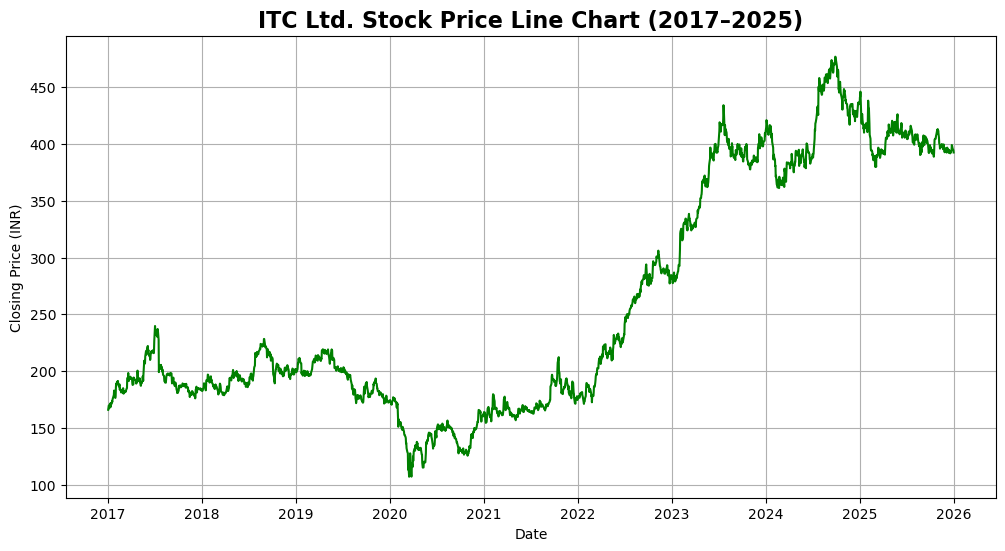

In [7]:
# Line chart 
plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], color='green')
plt.title("ITC Ltd. Stock Price Line Chart (2017–2025)", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")
plt.grid()
plt.show()

In [9]:
# The chart shows a general upward trend, indicating steady long-term growth.
# Minor fluctuations are visible, reflecting short-term market volatility.
# A clear dip around 2020 is followed by a strong and consistent recovery.

### Trend Analysis Using Moving Averages

In [11]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data

Price,Close,High,Low,Open,Volume,MA20,MA50
Date,,,,,,,
2017-01-02,166.090424,166.986530,164.470525,166.814194,5075736,NaN,NaN
2017-01-03,167.744797,169.364685,164.918606,166.055972,7798116,NaN,NaN
2017-01-04,169.192368,170.260798,165.504533,167.400144,9668664,NaN,NaN
2017-01-05,170.088455,170.846700,168.261769,168.537493,9532162,NaN,NaN
2017-01-06,167.296738,171.639429,166.952089,170.260791,8404984,NaN,NaN
...,...,...,...,...,...,...,...
2025-12-23,398.988159,400.506330,393.552068,394.237711,10081997,394.205878,398.102709
2025-12-24,398.253571,401.094035,397.323060,399.575865,5777430,394.416466,398.246693
2025-12-26,395.853851,398.792269,395.560021,398.155618,3152453,394.409120,398.390676


In [13]:
data['Trend'] = 'Downtrend'
data.loc[data['MA20'] > data['MA50'], 'Trend'] = 'Uptrend'
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend
Date,,,,,,,,
2017-01-02,166.090424,166.986530,164.470525,166.814194,5075736,NaN,NaN,Downtrend
2017-01-03,167.744797,169.364685,164.918606,166.055972,7798116,NaN,NaN,Downtrend
2017-01-04,169.192368,170.260798,165.504533,167.400144,9668664,NaN,NaN,Downtrend
2017-01-05,170.088455,170.846700,168.261769,168.537493,9532162,NaN,NaN,Downtrend
2017-01-06,167.296738,171.639429,166.952089,170.260791,8404984,NaN,NaN,Downtrend
...,...,...,...,...,...,...,...,...
2025-12-23,398.988159,400.506330,393.552068,394.237711,10081997,394.205878,398.102709,Downtrend
2025-12-24,398.253571,401.094035,397.323060,399.575865,5777430,394.416466,398.246693,Downtrend
2025-12-26,395.853851,398.792269,395.560021,398.155618,3152453,394.409120,398.390676,Downtrend


### Daily Returns

In [15]:
data['Daily Return'] = data['Close'].pct_change()
data

Price,Close,High,Low,Open,Volume,MA20,MA50,Trend,Daily Return
Date,,,,,,,,,
2017-01-02,166.090424,166.986530,164.470525,166.814194,5075736,NaN,NaN,Downtrend,NaN
2017-01-03,167.744797,169.364685,164.918606,166.055972,7798116,NaN,NaN,Downtrend,0.009961
2017-01-04,169.192368,170.260798,165.504533,167.400144,9668664,NaN,NaN,Downtrend,0.008630
2017-01-05,170.088455,170.846700,168.261769,168.537493,9532162,NaN,NaN,Downtrend,0.005296
2017-01-06,167.296738,171.639429,166.952089,170.260791,8404984,NaN,NaN,Downtrend,-0.016413
...,...,...,...,...,...,...,...,...,...
2025-12-23,398.988159,400.506330,393.552068,394.237711,10081997,394.205878,398.102709,Downtrend,0.011547
2025-12-24,398.253571,401.094035,397.323060,399.575865,5777430,394.416466,398.246693,Downtrend,-0.001841
2025-12-26,395.853851,398.792269,395.560021,398.155618,3152453,394.409120,398.390676,Downtrend,-0.006026


### Handling of missing values

In [17]:
# Replace first NaN in Daily Return
data['Daily Return'].fillna(0)

# Forward fill remaining missing values
data.ffill(inplace=True)

# Remove any remaining initial NaN rows (from MA20, MA50, etc.)
data.dropna(inplace=True)

# Final check
print(data.isnull().sum())

Price
Close           0
High            0
Low             0
Open            0
Volume          0
MA20            0
MA50            0
Trend           0
Daily Return    0
dtype: int64


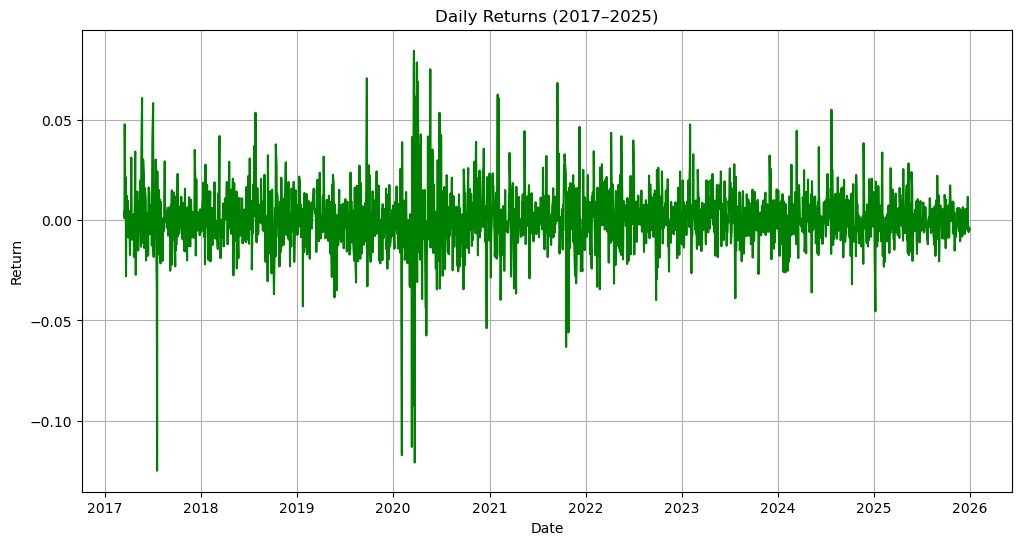

In [19]:
# Line chart (Daily Returns Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Daily Return'], color='green')
plt.title("Daily Returns (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid()
plt.show()

In [21]:
# Returns are mostly around zero, showing stable average performance.
# Small fluctuations are frequent, indicating normal market movement.
# Occasional sharp spikes show short-term volatility.
# Higher volatility is visible around 2020.
# Later years appear slightly more stable.

### Daily Volatility

In [23]:
daily_vol = data['Daily Return'].std()
print(f"Daily Volatility: {daily_vol*100:.2f}%")

Daily Volatility: 1.50%


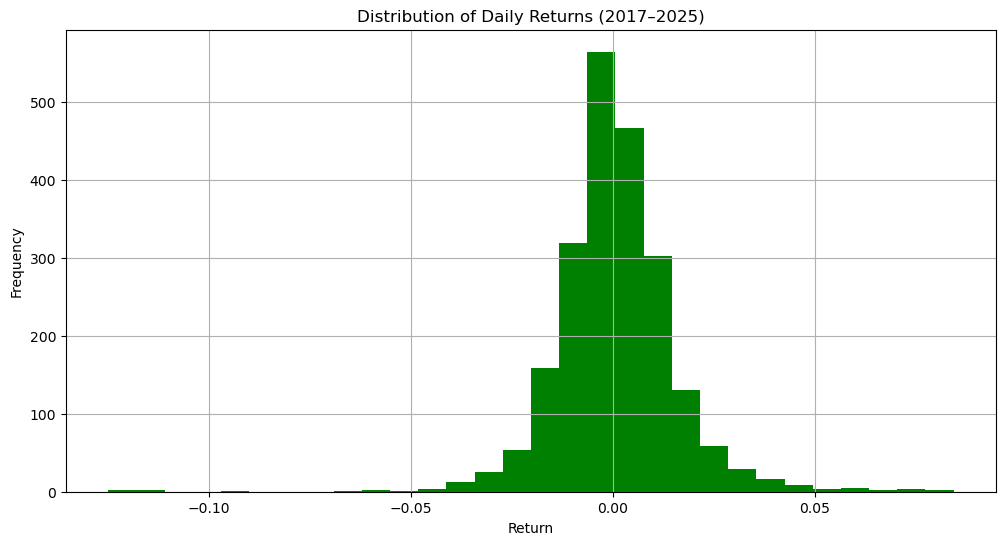

In [25]:
# Histogram (Distribution of Daily Returns)
plt.figure(figsize=(12,6))
plt.hist(data['Daily Return'].dropna(), bins=30, color='green')
plt.title("Distribution of Daily Returns (2017–2025)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [27]:
# Most returns are clustered around zero, indicating stable average performance.
# The distribution is approximately symmetric, suggesting consistent market behavior.
# A few extreme values on both sides indicate occasional high volatility.
# The spread of data suggests moderate risk in returns.

### Annualized Volatility

In [29]:
annual_vol = daily_vol * np.sqrt(252)
print(f"Annualized Volatility: {annual_vol*100:.2f}%")

Annualized Volatility: 23.83%


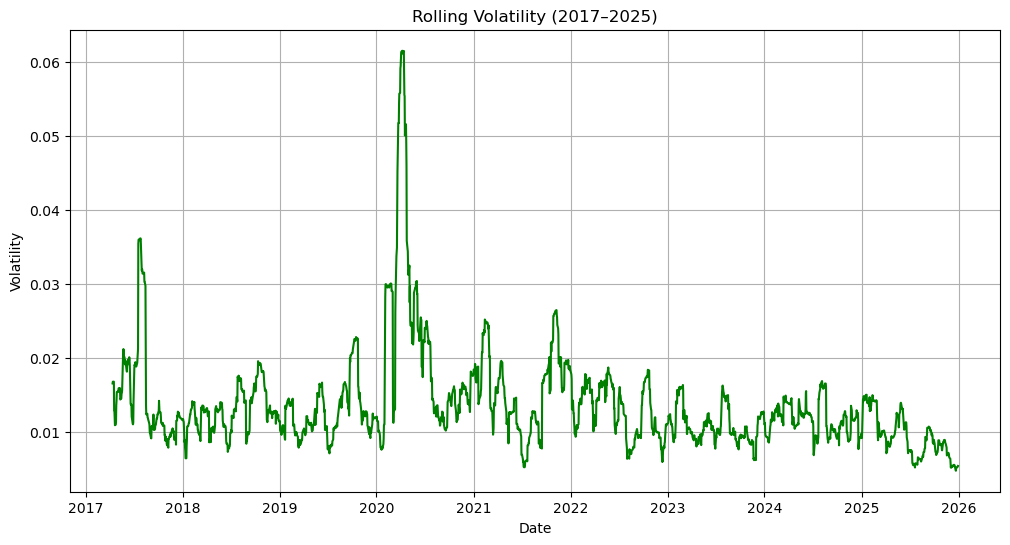

In [31]:
data['Rolling Volatility'] = data['Daily Return'].rolling(20).std()

# Line chart (Rolling Volatility Trend)
plt.figure(figsize=(12,6))
plt.plot(data['Rolling Volatility'], color='green')
plt.title("Rolling Volatility (2017–2025)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid()
plt.show()

In [33]:
# Volatility is generally low and stable for most of the period.
# Sharp spikes are visible (especially around 2020), indicating higher risk and uncertainty.
# After this period, volatility decreases and becomes more consistent.
# Recent years show relatively lower and controlled fluctuations.

### 📊 Conclusion

### ITC Limited stock shows relatively stable performance with moderate fluctuations over time.

### - Volatility remains low to moderate, indicating controlled market risk.

### - Price movements suggest a steady trend without extreme swings.

### - Daily returns highlight consistency with occasional short-term fluctuations.